# Catalog Coverage: Western, Non-Western, and International

This notebook quantifies how individuals from different polities are covered
by Western, non-Western, and international authority catalogs (library and biographical databases).
Catalogs are classified using the `country_name` field in `identifier_types`.

**Figure produced:** Stacked bar chart (%) of the top-10 polities ranked by non-Western-only share,
with Western, both, non-Western, international, and no-catalog segments.

## 1. Setup and Western country definition

Load the database and define the set of country names considered Western.

In [23]:
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import defaultdict

DB = '../data/humans_clean.sqlite3'

WESTERN_COUNTRIES = {
    'United States', 'Washington, D.C.', 'Germany', 'France', 'Poland',
    'Netherlands', 'Kingdom of the Netherlands', 'United Kingdom', 'Wales',
    'Italy', 'Kingdom of Italy', 'Spain', 'Sweden', 'Norway', 'Finland',
    'Denmark', 'Faroe Islands', 'Austria', 'Belgium', 'Switzerland',
    'Portugal', 'Czech Republic', 'Slovakia', 'Greece', 'Hungary',
    'Ireland', 'Canada', 'Australia', 'New Zealand', 'Romania', 'Croatia',
    'Serbia', 'Slovenia', 'Lithuania', 'Latvia', 'Estonia', 'Bulgaria',
    'Iceland', 'Luxembourg', 'Liechtenstein', 'Andorra', 'Cyprus',
    'Vatican City', 'Weimar Republic', 'German Reich',
}

## 2. Classify catalogs and pre-compute per-individual coverage

Each catalog (identifier type) is classified as Western, non-Western, international,
or unclassified based on its `country_name`.
A temporary table `ind_cat` records, for every individual, whether they appear in at
least one Western, non-Western, and/or international catalog.

In [ ]:
conn = sqlite3.connect(DB)
conn.execute('PRAGMA cache_size=-500000')

cur = conn.execute('SELECT property_id, country_name FROM identifier_types')
western_pids = set()
non_western_pids = set()
international_pids = set()
unclassified_pids = set()
for pid, country in cur:
    if country and country in WESTERN_COUNTRIES:
        western_pids.add(pid)
    elif country and country == 'internationality':
        international_pids.add(pid)
    elif country:
        non_western_pids.add(pid)
    else:
        unclassified_pids.add(pid)

print(f"Catalog classification (from identifier_types.country_name):")
print(f"  Western:        {len(western_pids)}")
print(f"  Non-Western:    {len(non_western_pids)}")
print(f"  International:  {len(international_pids)}")
print(f"  Unclassified:   {len(unclassified_pids)} (no country_name)")

conn.execute('DROP TABLE IF EXISTS temp.w_pids')
conn.execute('CREATE TEMP TABLE w_pids (pid TEXT PRIMARY KEY)')
conn.executemany('INSERT INTO w_pids VALUES (?)', [(p,) for p in western_pids])

conn.execute('DROP TABLE IF EXISTS temp.nw_pids')
conn.execute('CREATE TEMP TABLE nw_pids (pid TEXT PRIMARY KEY)')
conn.executemany('INSERT INTO nw_pids VALUES (?)', [(p,) for p in non_western_pids])

conn.execute('DROP TABLE IF EXISTS temp.intl_pids')
conn.execute('CREATE TEMP TABLE intl_pids (pid TEXT PRIMARY KEY)')
conn.executemany('INSERT INTO intl_pids VALUES (?)', [(p,) for p in international_pids])

print("\nPre-computing catalog type per individual (may take a few minutes)...")
conn.execute('DROP TABLE IF EXISTS temp.ind_cat')
conn.execute('''
    CREATE TEMP TABLE ind_cat AS
    SELECT i.wikidata_id,
           MAX(CASE WHEN wp.pid IS NOT NULL THEN 1 ELSE 0 END) as has_western,
           MAX(CASE WHEN nwp.pid IS NOT NULL THEN 1 ELSE 0 END) as has_non_western,
           MAX(CASE WHEN ip.pid IS NOT NULL THEN 1 ELSE 0 END) as has_international
    FROM identifiers i
    LEFT JOIN w_pids wp ON i.property_id = wp.pid
    LEFT JOIN nw_pids nwp ON i.property_id = nwp.pid
    LEFT JOIN intl_pids ip ON i.property_id = ip.pid
    GROUP BY i.wikidata_id
''')
conn.execute('CREATE INDEX temp.idx_ind_cat ON ind_cat(wikidata_id)')

row = conn.execute('''
    SELECT COUNT(*), SUM(has_western), SUM(has_non_western), SUM(has_international)
    FROM ind_cat
''').fetchone()
print(f"Done! {row[0]:,} individuals with identifiers")
print(f"  Referenced by a Western catalog:        {row[1]:,} ({row[1]/row[0]*100:.1f}%)")
print(f"  Referenced by a non-Western catalog:     {row[2]:,} ({row[2]/row[0]*100:.1f}%)")
print(f"  Referenced by an international catalog:  {row[3]:,} ({row[3]/row[0]*100:.1f}%)")

Catalog classification (from identifier_types.country_name):
  Western:        1042
  Non-Western:    394
  International:  1
  Unclassified:   868 (no country_name)

Pre-computing catalog type per individual (may take a few minutes)...


In [ ]:
import pandas as pd

df_ind_cat = pd.read_sql("SELECT * FROM ind_cat LIMIT 20", conn)
print("Per-individual catalog coverage (first 20 rows):")
df_ind_cat

Per-individual catalog coverage (first 20 rows):


,wikidata_id,has_western,has_non_western,has_international
0,Q10000001,0,0,0
1,Q1000006,1,1,0
2,Q100000852,1,0,0
3,Q100000854,1,0,0
4,Q100000857,1,0,0
5,Q10000101,1,0,0
6,Q1000015,1,1,0
7,Q1000034,1,0,0
8,Q1000045,1,0,0
9,Q1000048,1,0,0


## 3. Top 10 polities by non-Western-only catalog share

Polities with at least 2,000 individuals, ranked by the share of individuals
appearing only in non-Western catalogs. International catalogs are shown
as a separate category.

In [ ]:
cur = conn.execute('''
    SELECT c.polity_name,
           COUNT(*) AS total,
           SUM(CASE WHEN COALESCE(ic.has_western,0)=1 AND COALESCE(ic.has_non_western,0)=0 THEN 1 ELSE 0 END) AS w_only,
           SUM(CASE WHEN COALESCE(ic.has_western,0)=1 AND COALESCE(ic.has_non_western,0)=1 THEN 1 ELSE 0 END) AS both_cat,
           SUM(CASE WHEN COALESCE(ic.has_western,0)=0 AND COALESCE(ic.has_non_western,0)=1 THEN 1 ELSE 0 END) AS nw_only,
           SUM(CASE WHEN COALESCE(ic.has_western,0)=0 AND COALESCE(ic.has_non_western,0)=0
                     AND COALESCE(ic.has_international,0)=1 THEN 1 ELSE 0 END) AS intl_only,
           SUM(CASE WHEN COALESCE(ic.has_western,0)=0 AND COALESCE(ic.has_non_western,0)=0
                     AND COALESCE(ic.has_international,0)=0 THEN 1 ELSE 0 END) AS no_catalog
    FROM consolidate c
    LEFT JOIN ind_cat ic ON c.wikidata_id = ic.wikidata_id
    WHERE c.polity_name IS NOT NULL
    GROUP BY c.polity_name
    HAVING total >= 2000
''')

raw_rows = cur.fetchall()

def clean_polity_name(compound):
    for part in compound.split(';'):
        part = part.strip()
        if not part.startswith('('):
            return part
    return compound.split(';')[0].strip('() ')

seen = {}
for polity_name, total, w_only, both_cat, nw_only, intl_only, no_catalog in raw_rows:
    display_name = clean_polity_name(polity_name)
    if display_name not in seen or nw_only > seen[display_name][4]:
        seen[display_name] = (polity_name, total, w_only, both_cat, nw_only, intl_only, no_catalog)

polity_rows = sorted(seen.values(), key=lambda r: r[4] / r[1], reverse=True)[:10]

print(f"{'Polity':<40} {'Total':>8} {'W only':>8} {'Both':>8} {'NW only':>8} {'Intl':>8} {'None':>8} {'NW %':>6}")
print('-' * 100)
for polity_name, total, w_only, both_cat, nw_only, intl_only, no_catalog in polity_rows:
    display_name = clean_polity_name(polity_name)
    print(f"{display_name:<40} {total:>8,} {w_only:>8,} {both_cat:>8,} {nw_only:>8,} {intl_only:>8,} {no_catalog:>8,} {nw_only/total*100:>5.1f}%")

Polity                                      Total   W only     Both  NW only     Intl     None   NW %
----------------------------------------------------------------------------------------------------
Oriental Republic of Uruguay               16,418      849    2,745    9,190      121    3,513  56.0%
Russian Federation                         68,539    9,533    7,692   15,746      964   34,604  23.0%
Republic of Indonesia                      93,326    3,549      854   19,345      615   68,963  20.7%
Iraqi Republic                              3,047      397      262      528      131    1,729  17.3%
Hungarian Republic                          2,096      514       31      350       14    1,187  16.7%
Federated Republic of Brazil               12,284    2,227    1,186    1,991      886    5,994  16.2%
Empire of Japan                            35,603    1,286    9,283    5,700        0   19,334  16.0%
Tanzania                                    3,425      192       69      540      2

In [ ]:
df_top10 = pd.DataFrame(
    [(clean_polity_name(r[0]), r[1], r[2], r[3], r[4], r[5], r[6]) for r in polity_rows],
    columns=['polity', 'total', 'western_only', 'both', 'non_western_only', 'international_only', 'no_catalog']
)
df_top10['nw_pct'] = (df_top10['non_western_only'] / df_top10['total'] * 100).round(1)
print("Top 10 polities by non-Western-only catalog share:")
df_top10

Top 10 polities by non-Western-only catalog share:


,polity,total,western_only,both,non_western_only,international_only,no_catalog,nw_pct
0,Oriental Republic of Uruguay,16418,849,2745,9190,121,3513,56.0
1,Russian Federation,68539,9533,7692,15746,964,34604,23.0
2,Republic of Indonesia,93326,3549,854,19345,615,68963,20.7
3,Iraqi Republic,3047,397,262,528,131,1729,17.3
4,Hungarian Republic,2096,514,31,350,14,1187,16.7
5,Federated Republic of Brazil,12284,2227,1186,1991,886,5994,16.2
6,Empire of Japan,35603,1286,9283,5700,0,19334,16.0
7,Tanzania,3425,192,69,540,226,2398,15.8
8,Brazilian Republic,13972,1414,409,2024,281,9844,14.5
9,Japan,182190,19911,51761,25426,1025,84067,14.0


In [ ]:
df_top10['percent_non_western']=df_top10['non_western_only']/df_top10['total']
df_top10.sort_values('percent_non_western', ascending=False)

,polity,total,western_only,both,non_western_only,international_only,no_catalog,nw_pct,percent_non_western
0,Oriental Republic of Uruguay,16418,849,2745,9190,121,3513,56.0,0.559751
1,Russian Federation,68539,9533,7692,15746,964,34604,23.0,0.229738
2,Republic of Indonesia,93326,3549,854,19345,615,68963,20.7,0.207284
3,Iraqi Republic,3047,397,262,528,131,1729,17.3,0.173285
4,Hungarian Republic,2096,514,31,350,14,1187,16.7,0.166985
5,Federated Republic of Brazil,12284,2227,1186,1991,886,5994,16.2,0.162081
6,Empire of Japan,35603,1286,9283,5700,0,19334,16.0,0.160099
7,Tanzania,3425,192,69,540,226,2398,15.8,0.157664
8,Brazilian Republic,13972,1414,409,2024,281,9844,14.5,0.144861
9,Japan,182190,19911,51761,25426,1025,84067,14.0,0.139558


### Figure: Top-10 polities by non-Western-only share (%)

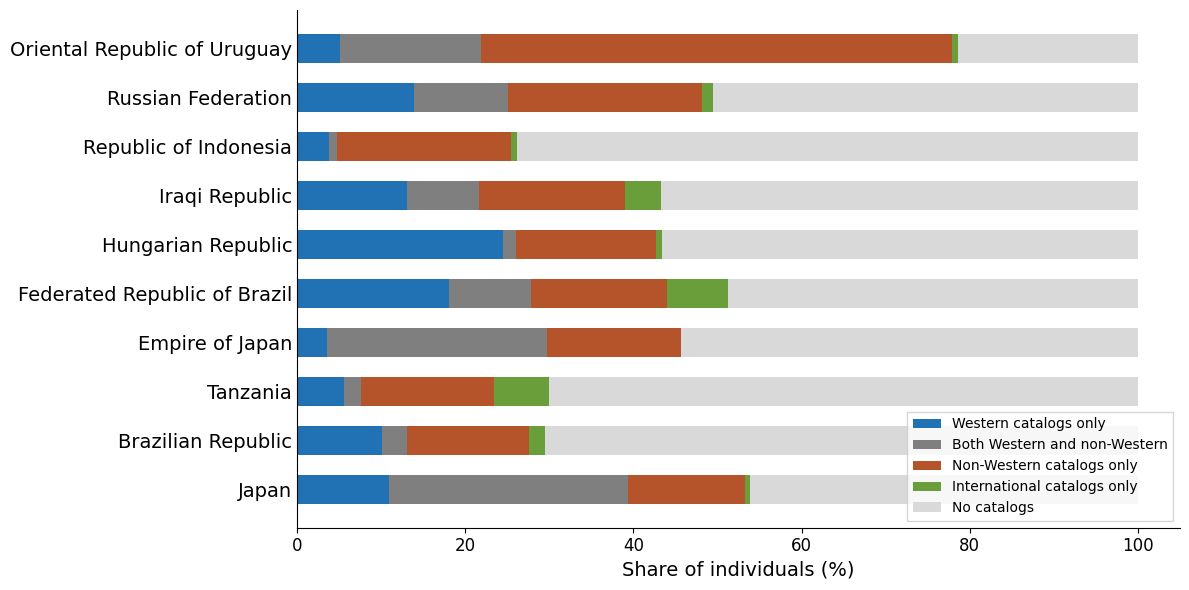

In [ ]:
labels_p    = [clean_polity_name(r[0]) for r in polity_rows]
totals      = np.array([r[1] for r in polity_rows], dtype=float)
w_only_p    = np.array([r[2] for r in polity_rows]) / totals * 100
both_p      = np.array([r[3] for r in polity_rows]) / totals * 100
nw_only_p   = np.array([r[4] for r in polity_rows]) / totals * 100
intl_only_p = np.array([r[5] for r in polity_rows]) / totals * 100
no_cat_p    = np.array([r[6] for r in polity_rows]) / totals * 100

labels_p    = labels_p[::-1]
w_only_p    = w_only_p[::-1]
both_p      = both_p[::-1]
nw_only_p   = nw_only_p[::-1]
intl_only_p = intl_only_p[::-1]
no_cat_p    = no_cat_p[::-1]

y = np.arange(len(labels_p))
height = 0.6

fig, ax = plt.subplots(figsize=(12, 6))

ax.barh(y, w_only_p,    height=height, color='#2171b5', label='Western catalogs only')
ax.barh(y, both_p,      height=height, left=w_only_p, color='#7f7f7f', label='Both Western and non-Western')
ax.barh(y, nw_only_p,   height=height, left=w_only_p + both_p, color='#b5542a',
        label='Non-Western catalogs only')
ax.barh(y, intl_only_p, height=height, left=w_only_p + both_p + nw_only_p,
        color='#6a9e3a', label='International catalogs only')
ax.barh(y, no_cat_p,    height=height, left=w_only_p + both_p + nw_only_p + intl_only_p,
        color='#d9d9d9', label='No catalogs')

ax.set_yticks(y)
ax.set_yticklabels(labels_p, fontsize=14)
ax.set_xlabel('Share of individuals (%)', fontsize=14)
ax.set_xlim(0, 105)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', length=0)
ax.legend(fontsize=10, loc='lower right', frameon=True,
          fancybox=False, edgecolor='#cccccc')

plt.tight_layout()
plt.show()

## Cleanup

In [ ]:
conn.close()